In [93]:
# pour changer la largeur de la page htlm générée par Jupyter :
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

# TP : Exploration et Analyse de Données avec Pandas et Streamlit

## Objectif

Ce projet vise à développer vos compétences en manipulation et analyse de données à l'aide de la bibliothèque Pandas en Python. Vous apprendrez à :

- Importer et explorer des données provenant de Kaggle.
- Effectuer des requêtes et manipulations de type SQL avec Pandas.
- Créer des visualisations interactives avec Streamlit.

Ce projet est noté. Tous les codes devront être écrits en Python dans des champs *jupyter* et devront respecter les conventions de nommage. L'énoncé **ne doit pas être modifié**.

La derniere séance du projet, vous déposerez le fichier jupyter (projetSAE.ipynb) sur la plateforme pédagogique.


##### Procédure à réaliser avant les séances de TD (nous utiliserons désormais jupyter lab)
- Lancer Anaconda Prompt sous Windows
- Saisissez dans Anaconda Prompt : 
conda create -n projet python pandas numpy matplotlib jupyterlab kagglehub seaborn streamlit plotly

=> à la demande "Proceed ([y]/n)?" saisissez y (ou juste pressez sur la touche "entrée")
=> "Executing transaction" prend du temps, c'est normal
Saisissez dans Anaconda Prompt : 
conda activate projet

##### Saisissez dans Anaconda Prompt : 
jupyter lab --notebook-dir="h:/"
Ouvrir projetSAE.ipynb dans Jupyter

In [94]:
%matplotlib notebook
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import streamlit as st

### Partie 1 : importation et exploration des données

#### Travailler avec Git
1 - En utilisant le prompt conda : initialiser le projet 

2 - Ajouter le fichier Jupyter Notebook et faite votre premier commit 
 
3 -  Creer un projet sur github dépôt distant (sans README.md )

4 - Pousser le projet vers ce dépôt 

5 - Enlever les checkpoint de jupyter 

#### Questions
1. Téléchargez le Dataset **Data Science Salaries 2023** sur Kaggle (https://www.kaggle.com/datasets/) via **kagglehub**.
2. Copier le fichier du cache au répertoire du projet, décompresser et visualiser le fichier CSV **ds_salaries.csv**
3. Importez le fichiers CSV avec Pandas.

##### Votre code

In [95]:
import kagglehub
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\e2305182\.cache\kagglehub\datasets\arnabchaki\data-science-salaries-2023\versions\1


##### Une bonne pratique 
- Copier les données téléchargées et les coller dans le répertoire du projet.
Pour cela, utilisez la bibliothéque os et shutil

In [96]:
# Répertoire cible dans votre projet
#mkdir input #creation du dossier input pour les mettres les données d'entrée

project_dir = "h:/Mes documents/Téléchargements/Projet-20260204/projet_notebook/input/"

# Créer le répertoire (si nécessaire)
os.makedirs(project_dir, exist_ok=True)

# Copier le fichier depuis le cache au répertoire du projet
cache_file = r"C:\Users\e2305182\.cache\kagglehub\datasets\arnabchaki\data-science-salaries-2023\versions\1\ds_salaries.csv"
shutil.copy(cache_file, project_dir)

'h:/Mes documents/Téléchargements/Projet-20260204/projet_notebook/input/ds_salaries.csv'

In [97]:
# Lire le fichier depuis le répertoire du projet
path = r"h:/Mes documents/Téléchargements/Projet-20260204/projet_notebook/input/ds_salaries.csv" #chemin d'acces du fichier
data = pd.read_csv(path) 
data

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


### Partie 2 : Analyses exploratoires

#### Question 1 :
Nous Souhaitons :

1. Connaitre est ce qu'il y a des données manquantes dans notre dataset.
2. Voir la distribution des salaires en USD avec la bibliothèque seaborn sous fome d'histogramme
3. avoir la liste des pays concerné par l'étude 
4. connaitre les salaire moyen par rôle, par pays, par niveau d'expérience

#### Votre code

In [98]:
#données manquantes 
data.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

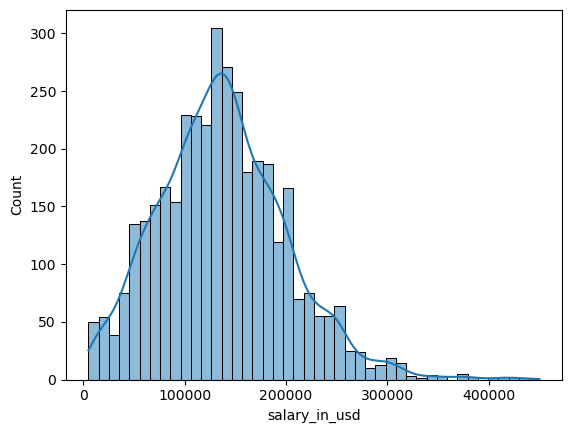

In [99]:
# Distribution des salaires en USD

%matplotlib inline

sns.histplot(data=data, x="salary_in_usd", kde=True)
plt.show()


On remarque que les salaire suivent une distribution symétrique avec des valeurs extrêmes

In [100]:
# liste des pays concerné par l'étude 
liste_pays = data["company_location"].unique() 
print(liste_pays)
print(len(liste_pays))

['ES' 'US' 'CA' 'DE' 'GB' 'NG' 'IN' 'HK' 'NL' 'CH' 'CF' 'FR' 'FI' 'UA'
 'IE' 'IL' 'GH' 'CO' 'SG' 'AU' 'SE' 'SI' 'MX' 'BR' 'PT' 'RU' 'TH' 'HR'
 'VN' 'EE' 'AM' 'BA' 'KE' 'GR' 'MK' 'LV' 'RO' 'PK' 'IT' 'MA' 'PL' 'AL'
 'AR' 'LT' 'AS' 'CR' 'IR' 'BS' 'HU' 'AT' 'SK' 'CZ' 'TR' 'PR' 'DK' 'BO'
 'PH' 'BE' 'ID' 'EG' 'AE' 'LU' 'MY' 'HN' 'JP' 'DZ' 'IQ' 'CN' 'NZ' 'CL'
 'MD' 'MT']
72


L'étude porte sur 72 pays

In [101]:
#Salaire moyen par rôle
salaire_par_role = data.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)
print("salaire_par_role")
print(salaire_par_role)
# Salaire moyen par pays
salaire_par_pays = data.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False)
print("\nsalaire_par_pays")
print(salaire_par_pays)
# Salaires moyens par niveau d'expérience

salaire_par_experience = data.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)
print("\nsalaire_par_experience")
print(salaire_par_experience)

salaire_par_role
job_title
Data Science Tech Lead           375000.000
Cloud Data Architect             250000.000
Data Lead                        212500.000
Data Analytics Lead              211254.500
Principal Data Scientist         198171.125
                                    ...    
Autonomous Vehicle Technician     26277.500
3D Computer Vision Researcher     21352.250
Staff Data Analyst                15000.000
Product Data Scientist             8000.000
Power BI Developer                 5409.000
Name: salary_in_usd, Length: 93, dtype: float64

salaire_par_pays
company_location
IL    271446.500000
PR    167500.000000
US    151822.009539
RU    140333.333333
CA    131917.689655
          ...      
VN     12000.000000
AL     10000.000000
MA     10000.000000
BO      7500.000000
MK      6304.000000
Name: salary_in_usd, Length: 72, dtype: float64

salaire_par_experience
experience_level
EX    194930.929825
SE    153051.071542
MI    104525.939130
EN     78546.284375
Name: salary_in_u

# Salaire par rôle
Les postes les plus seniors et spécialisés (Data Science Tech Lead , Cloud Data Architect, Data Lead ) touchent des salaires très élevés, parfois plusieurs millions.

Plus on descend vers des rôles d’analystes ou techniques d’entrée/milieu de carrière, plus les salaires chutent fortement.

L’écart est énorme : de 375 000  à 5 409 selon les rôles.

# Salaires par pays
Certains pays affichent des salaires exceptionnellement hauts (IL, PR, US…), probablement liés à des valeurs extrêmes ou à un faible nombre d’observations.

D’autres pays ont des salaires beaucoup plus bas (SE, MI, EN…).

Globalement, les salaires varient massivement selon le pays, ce qui reflète le coût de la vie et le marché local.

# Salaires par niveau d’expérience
MI (Mid-level) et EX (Senior/Expert) sont très proches en moyenne (~104k vs ~ 194k).

EN (Entry-level) est logiquement plus bas (~78k).

L’écart entre MI et EX est étonnamment faible, ce qui peut indiquer un marché où les salaires plafonnent vite

#### Question 2 :
Nous Souhaitons :

1. Filtrer les salaires pour un pays donné (ex : US)
2. Connaitre les top 5 des entreprises qui paient le plus

3. Filtrage et agrégation:
    - Afficher tous les employés dont le salaire est supérieur à 100 000 USD, ainsi que leur rôle.
    - Pays avec la plus forte proportion de télétravail (remote_ratio = 100)
       
4. Requêtes conditionnelles: 
    - Salaire moyen des employés à distance (100%)
    - Comparer salaires moyens pour deux catégories
        
5. Ajouter une colonne pour les fourchettes de salaires
6. Corrélations : Relation entre télétravail et salaire: 
 -
7. Salaire moyen par taille d'entreprise 
8. faire un tableau croisé : Moyenne des salaires par niveau d'expérience et télétravail

In [102]:
# Filtrer les salaires pour un pays donné (ex : US)
filtre = data[data["company_location"]=="US"]
print(filtre)

      work_year experience_level employment_type                 job_title  \
1          2023               MI              CT               ML Engineer   
2          2023               MI              CT               ML Engineer   
5          2023               SE              FT         Applied Scientist   
6          2023               SE              FT         Applied Scientist   
9          2023               SE              FT            Data Scientist   
...         ...              ...             ...                       ...   
3749       2021               SE              FT           Data Specialist   
3750       2020               SE              FT            Data Scientist   
3751       2021               MI              FT  Principal Data Scientist   
3752       2020               EN              FT            Data Scientist   
3753       2020               EN              CT     Business Data Analyst   

      salary salary_currency  salary_in_usd employee_residence 

Il y'a 3040 observations sur des personnes occupants des postes dans la data aux US

In [103]:
# Top 5 des entreprises qui paient le plus
top_5_entreprises = (
    data.groupby("employment_type")["salary_in_usd"]
        .mean() #pour calculer la moyenne 
        .sort_values(ascending=False) # trier de façon décroissante
        .head(5) # pour avoir le top 5
)
top_5_entreprises

employment_type
FT    138314.199570
CT    113446.900000
FL     51807.800000
PT     39533.705882
Name: salary_in_usd, dtype: float64

FT (Full‑time / CDI) : ~138 314 USD
C’est la forme d’emploi la mieux rémunérée. Les postes à temps plein offrent stabilité, avantages et souvent des rôles plus qualifiés, ce qui explique ce niveau de salaire.

CT (Contract / CDD) : ~113 447 USD
Les contrats temporaires restent bien payés, mais en dessous du CDI. Ils concernent souvent des missions ponctuelles ou moins stratégiques.

FL (Freelance) : ~51 808 USD
Les FREELANCE gagnent moins, ce qui peut s'exoliquer par une forte présence de freelances dans des pays à bas salaires,Des missions courtes ou peu spécialisées,une grandE variabilité selon les marchés.

PT (Part‑time / Temps partiel) : ~39 534 USD
Logiquement le plus bas, car le volume horaire est réduit et les postes sont souvent moins qualifiés.

# Top 5 des entreprises qui paient le plus par pays
top5_roles_par_pays = (
    data.groupby("company_location")
        .apply(lambda df: df.groupby("employment_type")["salary_in_usd"]
                            .mean()
                            .nlargest(5)) # fonction pour garder les 5 plus grands type d'entreprise par salaire 
        .reset_index()                    # pour chaque pays
)

print(top5_roles_par_pays)


Par ailleurs on que les salaire pour un même type de contrat dépendent fortement du pays

In [104]:
# Filtrer les données
# Rôles avec un salaire moyen supérieur à 100,000
roles_bien_payes = (
    data.groupby("job_title")["salary_in_usd"]
        .mean() # calculer la moyenne
        .loc[lambda x: x > 100000] # appliquer une fonction pour garder uniquement ceux supérieur à 100000
        .sort_values(ascending=False) # trier de façon décroissante
)
print("\nRôles avec un salaire moyen supérieur à 100,000 :")
print(roles_bien_payes)
# Pays avec la plus forte proportion de télétravail (remote_ratio = 100)
full_remote = data[data["remote_ratio"] == 100] # filtrer les lignes en full remote
pays_full_remote = (
    full_remote["company_location"]
        .value_counts() #retourne le
)
print("\nPays full remote")
print(pays_full_remote)


Rôles avec un salaire moyen supérieur à 100,000 :
job_title
Data Science Tech Lead                      375000.000000
Cloud Data Architect                        250000.000000
Data Lead                                   212500.000000
Data Analytics Lead                         211254.500000
Principal Data Scientist                    198171.125000
Director of Data Science                    195140.727273
Principal Data Engineer                     192500.000000
Machine Learning Software Engineer          192420.000000
Data Science Manager                        191278.775862
Applied Scientist                           190264.482759
Principal Machine Learning Engineer         190000.000000
Head of Data                                183857.500000
Data Infrastructure Engineer                175051.666667
Business Intelligence Engineer              174150.000000
Machine Learning Scientist                  163220.076923
Research Engineer                           163108.378378
Data Archit

## Rôles les mieux payés
Les postes dépassant 100 000 USD sont très majoritairement des rôles seniors, techniques ou managériaux dans la data et le machine learning.

Les mieux rémunérés
- Data Science Tech Lead (~375k)

- Cloud Data Architect (~250k)

- Data Lead, Data Analytics Lead (~210k)

- Principal Data Scientist (~198k)

- Director of Data Science, Principal Data Engineer, ML Software Engineer (~190k)

Les rôles juste au-dessus de 100k
- Data Scientist (~141k)

- Data Engineer (~142k)

- ML Engineer (~154k)

- BI Analyst (~105k)

- Financial Data Analyst (~102k)
Ce sont des postes techniques solides, mais pas au niveau “executive”.

## Pays full remote

Le full remote est surtout porté par les pays anglo‑saxons (US, UK, CA), avec une dominance aux Etats-Unis.

L’Europe continentale suit, mais avec des volumes plus modestes.

Les pays émergents (IN, BR, NG…) sont présents, souvent via des entreprises internationales.

La majorité des autres pays n’ont qu’une présence marginale.

In [105]:
# Requêtes conditionnelles
# Salaire moyen des employés à distance (100%)
salaire_moyen_remote = data[data["remote_ratio"] == 100]["salary_in_usd"].mean()
print(f"\nSalaire moyen des employés à distance (100%) :${salaire_moyen_remote:,.2f}")

# Comparer salaires moyens pour deux catégories
# Filtrer les employés en télétravail complet (remote_ratio = 100)
salaire_remote_100 = data[data["remote_ratio"] == 100]["salary_in_usd"].mean()

# Filtrer les employés sans télétravail (remote_ratio = 0)
salaire_remote_0 = data[data["remote_ratio"] == 0]["salary_in_usd"].mean()

# Afficher la comparaison
print(f"Salaire moyen (100% remote): ${salaire_remote_100:,.2f}")
print(f"Salaire moyen (0% remote): ${salaire_remote_0:,.2f}")
print(f"Différence: ${salaire_remote_100 - salaire_remote_0:,.2f}")


Salaire moyen des employés à distance (100%) :$136,481.45
Salaire moyen (100% remote): $136,481.45
Salaire moyen (0% remote): $144,316.20
Différence: $-7,834.75


Le salaire moyen des employés 100 % remote est d'environ $136,481.45. Celui des employé en présentiel est d'environ $144,316.20.
Les employés 100 % remote gagnent en moyenne $7 835 de moins que ceux qui ne sont jamais en remote.

In [106]:
# Ajouter une colonne pour les fourchettes de salaires

data['salary_range'] = pd.cut(data['salary_in_usd'], 
                               bins=[0, 50000, 100000, 150000, float('inf')],
                               labels=['<50k', '50k-100k', '100k-150k', '150k+'])

print("Données avec fourchettes de salaires :")
print(data[['salary_in_usd', 'salary_range']].head())

print("\nPays avec les salaires moyens les plus élevés :")
print(data.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head())


Données avec fourchettes de salaires :
   salary_in_usd salary_range
0          85847     50k-100k
1          30000         <50k
2          25500         <50k
3         175000        150k+
4         120000    100k-150k

Pays avec les salaires moyens les plus élevés :
employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    152822.011651
CA    132222.905882
Name: salary_in_usd, dtype: float64


In [107]:
data['salary_range'] = pd.cut(data['salary_in_usd'], 
                               bins=[0, 50000, 100000, 150000, float('inf')],
                               labels=['<50k', '50k-100k', '100k-150k', '150k+'])

print("Données avec fourchettes de salaires :")

print(data[['salary_in_usd', 'salary_range']].head())

print("\nPays avec les salaires moyens les plus élevés :")
print(data.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head())


Données avec fourchettes de salaires :
   salary_in_usd salary_range
0          85847     50k-100k
1          30000         <50k
2          25500         <50k
3         175000        150k+
4         120000    100k-150k

Pays avec les salaires moyens les plus élevés :
employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    152822.011651
CA    132222.905882
Name: salary_in_usd, dtype: float64


On remarqu que les salire sont presque également répartis dans les quatres fourchettes, avec plus de salarié au dessus des 150k

Corrélation télétravail-salaire : -0.06417098519057557

Salaire moyen par ratio de télétravail :
remote_ratio
0      144316.202288
50      78400.687831
100    136481.452830
Name: salary_in_usd, dtype: float64


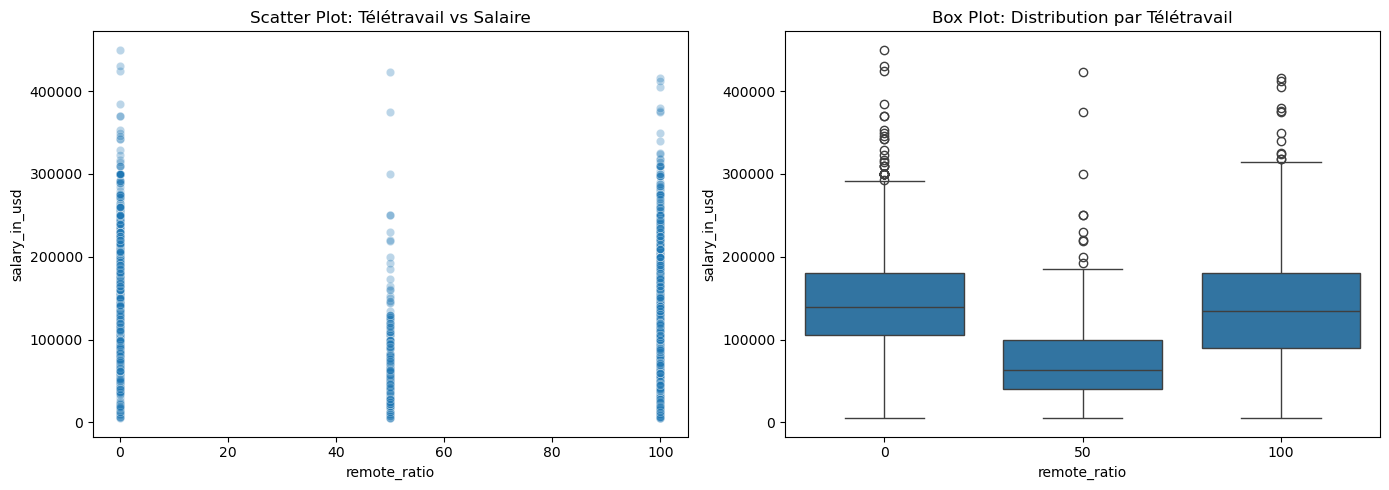

In [108]:
# Analyse des corrélations
# Relation entre télétravail et salaire

# Corrélation
print("Corrélation télétravail-salaire :", 
      data['remote_ratio'].corr(data['salary_in_usd']))

# Salaire moyen par ratio
print("\nSalaire moyen par ratio de télétravail :")
print(data.groupby('remote_ratio')['salary_in_usd'].mean())

# Visualisation avec seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=data, x='remote_ratio', y='salary_in_usd', alpha=0.3, ax=axes[0])
axes[0].set_title('Scatter Plot: Télétravail vs Salaire')

sns.boxplot(data=data, x='remote_ratio', y='salary_in_usd', ax=axes[1])
axes[1].set_title('Box Plot: Distribution par Télétravail')

plt.tight_layout()
plt.show()


La valeur du coefficient de corrélarion est très proche de 0, légèrement négative.

Cela signifie qu’il n’existe pratiquement pas de relation entre le niveau de télétravail et le salaire.

Autrement dit : le télétravail n’influence pas vraiment le salaire dans ce dataset.

Statistiques par taille d'entreprise :
                       mean    median  count
company_size                                
L             118300.982379  108500.0    454
M             143130.548367  140000.0   3153
S              78226.682432   62146.0    148


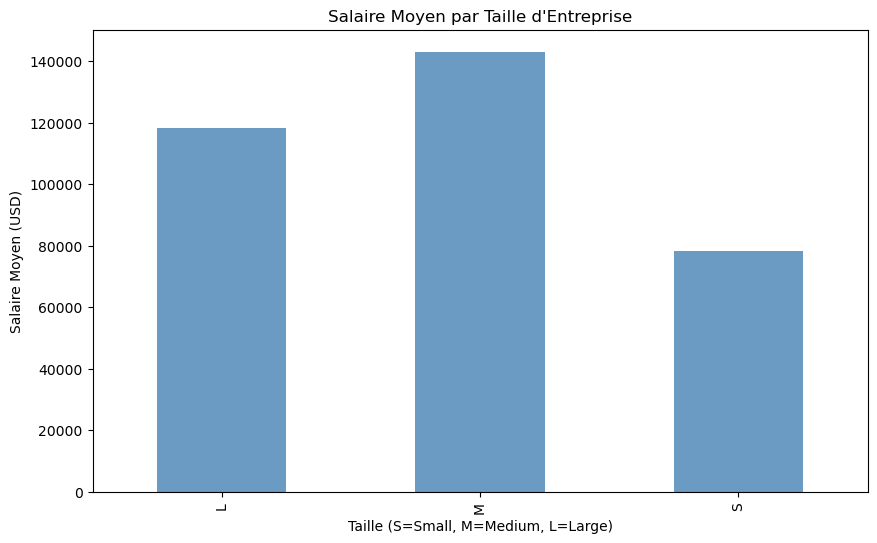

In [109]:
# Salaire moyen par taille d'entreprise
salaire_par_taille = data.groupby('company_size')['salary_in_usd'].agg(['mean', 'median', 'count'])
print("Statistiques par taille d'entreprise :")
print(salaire_par_taille)

# Graphique
plt.figure(figsize=(10, 6))
salaire_par_taille['mean'].plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Salaire Moyen par Taille d\'Entreprise')
plt.xlabel('Taille (S=Small, M=Medium, L=Large)')
plt.ylabel('Salaire Moyen (USD)')
plt.show()


On remarque que les entreprises de taille moyenne (M) offrent les meilleurs salaires en moyenne.
Elles dominent largement, avec une médiane très élevée et un grand nombre d’employés dans le dataset.

Les grandes entreprises (L) paient bien, mais moins que les entreprises moyennes.
Cela peut s’expliquer par une plus grande diversité de postes, y compris des rôles moins rémunérés.

Les petites entreprises (S) sont celles qui rémunèrent le moins.
Les salaires y sont nettement plus bas, ce qui est cohérent avec leurs ressources plus limitées.

Tableau croisé des salaires :
remote_ratio                0              50             100
experience_level                                             
EN                104581.765766   64006.230769   65040.486111
EX                182435.785714  139030.166667  214837.326923
MI                116723.103535   74214.405405   96803.480597
SE                154024.064706   98438.136364  154022.023381


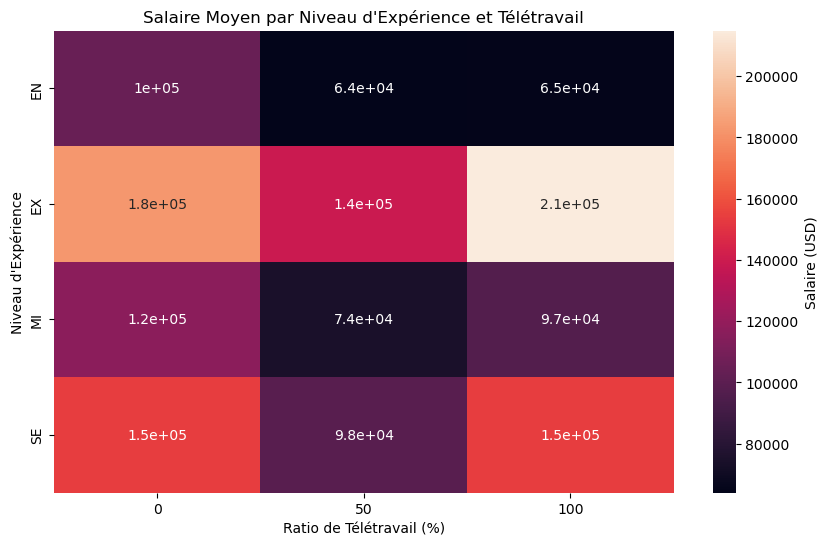

In [110]:
# Tableaux croisés
# Moyenne des salaires par niveau d'expérience et télétravail
pivot_table = data.pivot_table(
    index='experience_level', 
    columns='remote_ratio', 
    values='salary_in_usd', 
    aggfunc='mean'
)
print("Tableau croisé des salaires :")
print(pivot_table)

# Visualisation avec une carte de chaleur
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cbar_kws={'label': 'Salaire (USD)'})
plt.title('Salaire Moyen par Niveau d\'Expérience et Télétravail')
plt.xlabel('Ratio de Télétravail (%)')
plt.ylabel('Niveau d\'Expérience')
plt.show()


 Le télétravail n’a pas le même effet selon l’expérience  
 Le 50% remote est systématiquement le moins payé  
 Le full remote (100%) devient avantageux pour les profils très expérimentés